## profilage_longueur_documents_bofip

**Fichier(s) source :** `./data/bofip_stock_live_20260521.tgz` (stock du 21.05.2026)

**Fichier(s) de sortie :** `./data/figure_longueur_documents_bofip.png` (figure)

**Description :** Mesure de la longueur (nombre de caractères) des documents de la famille Contenu du stock BOFiP et distribution de ces longueurs : statistiques descriptives, document le plus long, et histogramme.

## Étape 1 — Charger le stock

In [1]:
from pathlib import Path
import tarfile

CHEMIN_STOCK = Path(
    r"./data/bofip_stock_live_20260521.tgz"
)

if not CHEMIN_STOCK.exists():
    print("Archive introuvable :", CHEMIN_STOCK)
else:
    print("Archive chargee :", CHEMIN_STOCK.name)


Archive chargee : bofip_stock_live_20260521.tgz


## Étape 2 — Mesurer la longueur des documents Contenu

Parcours des fichiers `data.html` de la famille Contenu. Pour chaque document, sont conservés son identifiant, sa série, son type et le nombre de caractères de son contenu.


In [2]:
lignes = []

def est_contenu_html(nom_membre: str) -> bool:
    nom = nom_membre.replace("\\", "/")
    return ("documents/Contenu/" in nom) and nom.endswith("/data.html")

with tarfile.open(CHEMIN_STOCK, "r:gz") as tar:
    for membre in tar:
        if membre.isfile() and est_contenu_html(membre.name):
            fichier = tar.extractfile(membre)
            if fichier is not None:
                contenu = fichier.read().decode("utf-8", errors="replace")
                # Chemin type : .../Contenu/<Type>/<Serie>/<identifiant>/<date>/data.html
                parties = membre.name.replace("\\", "/").split("/")
                identifiant = parties[-3]   # dossier de l'identifiant (ex. 12088-PGP)
                serie = parties[-4]         # dossier de la serie (ex. BIC)
                type_doc = parties[-5]      # dossier du type (ex. Commentaire)
                lignes.append({
                    "identifiant": identifiant,
                    "serie": serie,
                    "type": type_doc,
                    "longueur": len(contenu),
                })

print(f"Documents Contenu mesures : {len(lignes)}")


Documents Contenu mesures : 6311


## Étape 3 — Statistiques descriptives et document le plus long

In [3]:
import pandas as pd

df = pd.DataFrame(lignes)
serie = df["longueur"]

print(f"Documents : {len(df)}")
print(f"Minimum   : {int(serie.min())} caracteres")
print(f"Mediane   : {int(serie.median())} caracteres")
print(f"Moyenne   : {int(serie.mean())} caracteres")
print(f"Maximum   : {int(serie.max())} caracteres")
print()

# Document le plus long
plus_long = df.loc[df["longueur"].idxmax()]
print("Document le plus long :")
print(f"  identifiant : {plus_long['identifiant']}")
print(f"  serie       : {plus_long['serie']}")
print(f"  type        : {plus_long['type']}")
print(f"  longueur    : {int(plus_long['longueur'])} caracteres")
print()

# Les 5 plus longs, pour contexte
print("Les 5 documents les plus longs :")
top5 = df.nlargest(5, "longueur")[["identifiant", "serie", "type", "longueur"]]
print(top5.to_string(index=False))
print()

# Repartition par tranche
tranches = [0, 500, 1000, 2000, 5000, 10000, 25000, 50000, 100000, int(serie.max()) + 1]
etiquettes = ["0-500", "500-1k", "1k-2k", "2k-5k", "5k-10k",
              "10k-25k", "25k-50k", "50k-100k", "100k et +"]
decoupage = pd.cut(serie, bins=tranches, labels=etiquettes, right=False)
print("Repartition par tranche :")
print(decoupage.value_counts().sort_index().to_string())


Documents : 6311
Minimum   : 226 caracteres
Mediane   : 7841 caracteres
Moyenne   : 14797 caracteres
Maximum   : 174637 caracteres

Document le plus long :
  identifiant : 6273-PGP
  serie       : IR
  type        : Autres annexes
  longueur    : 174637 caracteres

Les 5 documents les plus longs :
identifiant serie           type  longueur
   6273-PGP    IR Autres annexes    174637
   3889-PGP    IR    Commentaire    166507
   7650-PGP   INT Autres annexes    119941
  13464-PGP   TVA    Commentaire    104677
   5356-PGP   BIC    Commentaire    103303

Repartition par tranche :
longueur
0-500          82
500-1k        384
1k-2k         945
2k-5k        1266
5k-10k        775
10k-25k      1390
25k-50k      1202
50k-100k      260
100k et +       7


## Étape 4 — Histogramme des longueurs

Axe horizontal : longueur en caractères. Axe vertical : nombre de documents, échelle logarithmique.


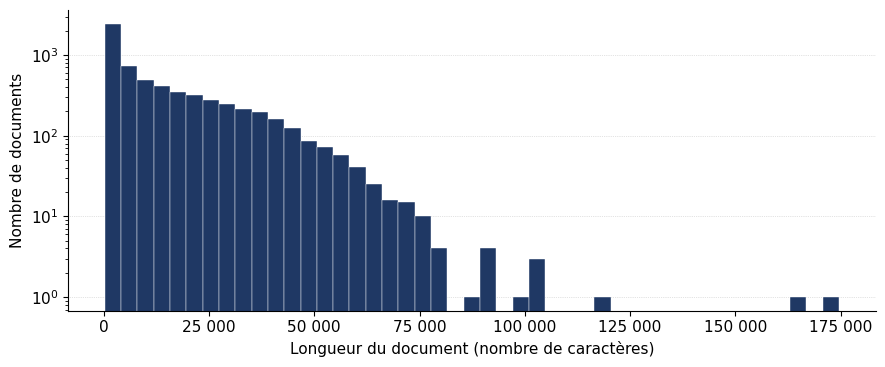

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator, LogFormatterMathtext

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.hist(serie, bins=45, color="#1F3864", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " "))
)

ax.set_xlabel("Longueur du document (nombre de caractères)")
ax.set_ylabel("Nombre de documents")

ax.grid(axis="y", which="major", linestyle=":", linewidth=0.5, color="#B0B0B0", alpha=0.7)
ax.set_axisbelow(True)
for cote in ["top", "right"]:
    ax.spines[cote].set_visible(False)

plt.tight_layout()
plt.show()


## Étape 5 — Enregistrer la figure

In [5]:
nom_fichier = CHEMIN_STOCK.parent / "figure_longueur_documents_bofip.png"
fig.savefig(nom_fichier, dpi=200, bbox_inches="tight")
print("Figure enregistree :", nom_fichier)


Figure enregistree : ./data/figure_longueur_documents_bofip.png
